# Diffusion Coefficient of Kob-Andersen mixture  

Kob-Andersen mixture is of 80% large A particles and 20% small B particles, with a strong A-B interaction. This mixture is known to be resistant to crystallization and can be used to study supercooled liquids/glasses. 

We will compute the mean-squared-displacement to see the slowdown in dynamics:


$ MSD(m) = \frac{1}{N_{particles}} \sum_{i=1}^{N_{particles}} \frac{1}{N-m} \sum_{k=0}^{N-m-1} (\vec{r}_i(k+m) - \vec{r}_i(k))^2$ 

Then compute the slope to get diffusion coefficient $D$. 

In [1]:
import numpy as np
import freud 
import matplotlib 
import matplotlib.pyplot as plt 
import gsd, gsd.hoomd

In [27]:
def analyze_msd(filename,timestep):
    trajectory =  gsd.hoomd.open(filename,'r')
    
    all_unwrapped_positions = []
    times = []
    
    box  = trajectory[0].configuration.box[0:3]
    time0 = trajectory[0].configuration.step 
    
    for frame in trajectory:
        unwrapped_positions = frame.particles.position +\
                              frame.particles.image*frame.configuration.box[0:3]
        
        unwrapped_positions = unwrapped_positions - np.mean(unwrapped_positions,axis=0)
        
        all_unwrapped_positions.append(unwrapped_positions)
        times.append(frame.configuration.step-time0)

    # shape = (nframes,nparticles,3)
    all_unwrapped_positions = np.array(all_unwrapped_positions)  
    msd_calculator = freud.msd.MSD()
    msd_calculator.compute(all_unwrapped_positions)
    result = msd_calculator.particle_msd
    msd = np.nanmean(result,axis=1)

    lagtimes = np.asarray(times)*timestep

    return lagtimes, msd

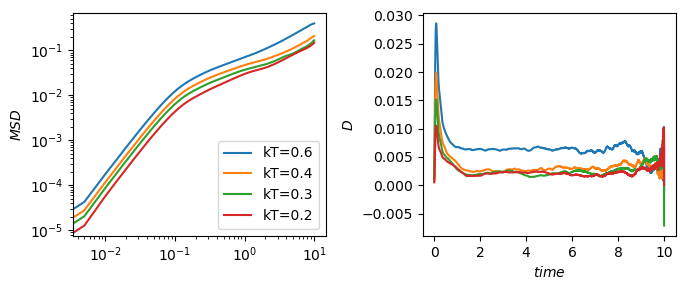

In [39]:
fig,ax = matplotlib.pyplot.subplots(1,2,figsize=(7,3))

timestep = 0.005

for kT in [0.6,0.4,0.3,0.2]:
    lagtimes, msd = analyze_msd("Kob-Andersen/KA_kT_%1.2f_short.gsd"%kT,timestep)
    ax[0].plot(lagtimes, msd,label='kT=%1.1f'%kT)
    gradient = np.gradient(msd, lagtimes)
    ax[1].plot(lagtimes,gradient/(6.0))

ax[0].set_ylabel(r"$MSD [\sigma^2]$")
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].legend()

ax[1].set_xlabel(r"$time [\tau]$")
ax[1].set_ylabel(r"$D [\sigma(\epsilon/m)^{1/2}]$")

matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

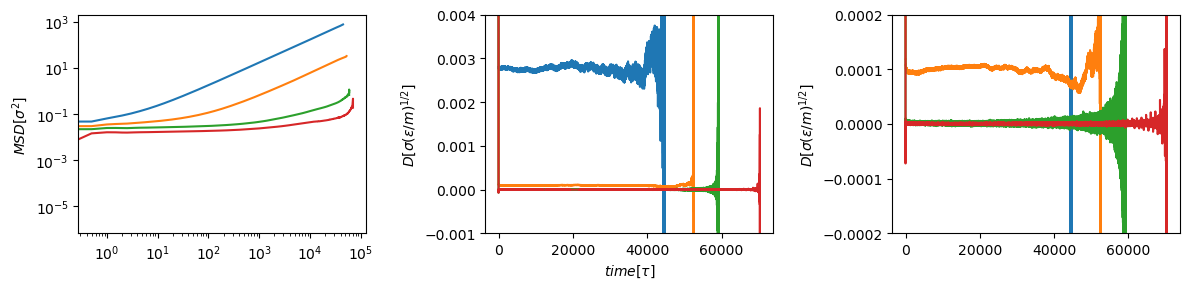

In [43]:
fig,ax = matplotlib.pyplot.subplots(1,3,figsize=(12,3))

timestep = 0.005

for kT in [0.6,0.4,0.3,0.2]:
    lagtimes, msd = analyze_msd("Kob-Andersen/KA_kT_%1.2f.gsd"%kT,timestep)
    ax[0].plot(lagtimes, msd)
    gradient = np.gradient(msd, lagtimes)
    ax[1].plot(lagtimes,gradient/(6.0))
    ax[2].plot(lagtimes,gradient/(6.0))

ax[0].set_ylabel(r"$MSD [\sigma^2]$")
ax[0].set_yscale('log')
ax[0].set_xscale('log')


ax[1].set_xlabel(r"$time [\tau]$")
ax[1].set_ylabel(r"$D [\sigma(\epsilon/m)^{1/2}]$")
ax[2].set_ylabel(r"$D [\sigma(\epsilon/m)^{1/2}]$")
ax[1].set_ylim([-0.001,0.004])
ax[2].set_ylim([-0.0002,0.0002])
matplotlib.pyplot.tight_layout()

matplotlib.pyplot.show()